## Pose Estimation from Erg Video

Using MediaPipe Pose Landmarker from Google

(Link)[https://developers.google.com/edge/mediapipe/solutions/vision/pose_landmarker/index?_gl=1*z8jxl0*_up*MQ..*_ga*NDE0OTUwMzcwLjE3OTA4NzQyMzU.*_ga_SM8HXJ53K2*czE3OTA4NzQyMzQkbzEkZzAkdDE3OTA4NzQyNDckajQ3JGwwJGgw#models]


In [1]:
import cv2
import mediapipe as mp
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# setup pose landmarker 


from mediapipe.tasks import python
from mediapipe.tasks.python import vision

model_path = "../models/pose_landmarker_full.task"

base_options = python.BaseOptions(
    model_asset_path=model_path
)

options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.IMAGE,
    num_poses=1
)

landmarker = vision.PoseLandmarker.create_from_options(options)

In [3]:
# capture a frame from the video

cap = cv2.VideoCapture("../assets/luke-erg.mp4")

ret, frame = cap.read()

cap.release()

print(frame.shape)

(2160, 3840, 3)


(-0.5, 3839.5, 2159.5, -0.5)

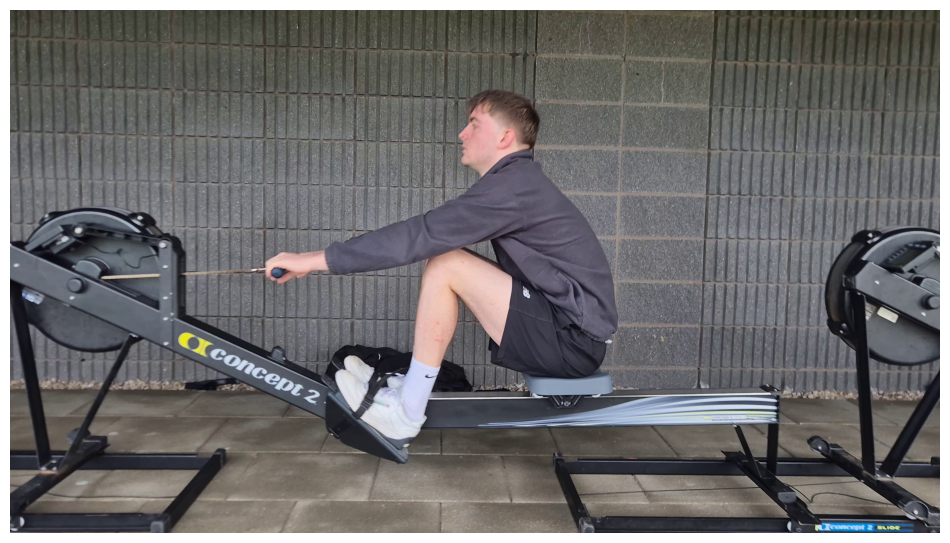

In [4]:
# display the captured frame

plt.figure(figsize=(12, 7))

plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

plt.axis("off")

In [5]:
# run pose estimation on captured frame

rbg_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

mp_image = mp.Image(
    image_format=mp.ImageFormat.SRGB, 
    data=rbg_frame)

result = landmarker.detect(mp_image)

len(result.pose_landmarks)

1

In [6]:
landmarks = result.pose_landmarks[0]

len(landmarks)

33

In [7]:
# display pose landmarks

for i, landmark in enumerate(landmarks):
    print(
        i, 
        round(landmark.x, 3),
        round(landmark.y, 3),
        round(landmark.z, 3), 
        round(landmark.visibility, 3),
    )

0 0.492 0.251 0.002 0.999
1 0.5 0.229 -0.02 0.999
2 0.503 0.229 -0.021 0.999
3 0.505 0.229 -0.021 1.0
4 0.499 0.228 0.018 1.0
5 0.5 0.228 0.018 1.0
6 0.501 0.227 0.018 1.0
7 0.521 0.241 -0.072 0.999
8 0.518 0.237 0.101 0.999
9 0.498 0.274 -0.014 0.999
10 0.496 0.273 0.036 0.999
11 0.535 0.349 -0.181 0.999
12 0.534 0.363 0.227 0.998
13 0.429 0.433 -0.25 0.917
14 0.448 0.452 0.259 0.023
15 0.325 0.48 -0.208 0.941
16 0.356 0.484 0.197 0.061
17 0.295 0.495 -0.249 0.937
18 0.342 0.485 0.21 0.09
19 0.293 0.49 -0.212 0.927
20 0.326 0.491 0.172 0.089
21 0.3 0.487 -0.194 0.892
22 0.332 0.487 0.178 0.096
23 0.6 0.633 -0.136 1.0
24 0.598 0.633 0.136 0.999
25 0.471 0.489 -0.127 0.973
26 0.473 0.491 0.273 0.044
27 0.421 0.737 -0.027 0.985
28 0.429 0.718 0.398 0.212
29 0.425 0.805 -0.018 0.971
30 0.444 0.762 0.409 0.254
31 0.348 0.702 -0.05 0.969
32 0.377 0.711 0.384 0.293


In [8]:
# draw pose landmarks and connections on the captured frame

connections = mp.tasks.vision.PoseLandmarksConnections.POSE_LANDMARKS
annotated = frame.copy()

height, width = frame.shape[:2]

for connection in connections:

    start_idx, end_idx = connection.start, connection.end

    start = landmarks[start_idx]
    end = landmarks[end_idx]

    start_point = (
        int(start.x * width),
        int(start.y * height)
    )

    end_point = (
        int(end.x * width),
        int(end.y * height)
    )

    cv2.line(
        annotated,
        start_point,
        end_point,
        (0, 255, 0),
        2
    )

for landmark in landmarks:

    point = (
        int(landmark.x * width),
        int(landmark.y * height)
    )

    cv2.circle(
        annotated,
        point,
        5,
        (255, 0, 0),
        -1
    )

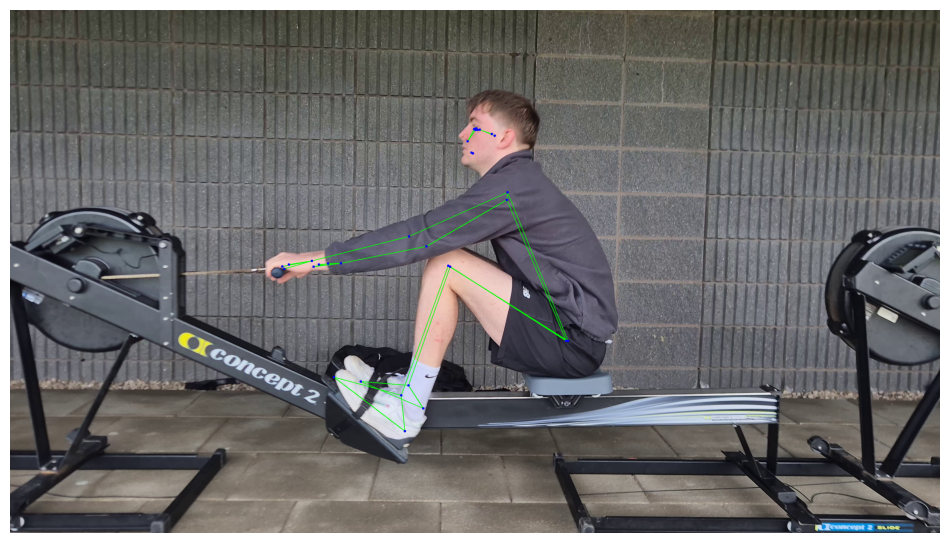

In [9]:
# display the annotated frame with pose landmarks and connections

plt.figure(figsize=(12, 7))

plt.imshow(
    cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
)

plt.axis("off");

In [15]:
# map landmarks to strings for rowing analysis
ROWING_LANDMARKS: dict[str, int] = {
    "nose": 0,
    "left_ear": 7,
    "right_ear": 8,
    "left_shoulder": 11,
    "right_shoulder": 12,
    "left_elbow": 13,
    "right_elbow": 14,
    "left_wrist": 15,
    "right_wrist": 16,
    "left_hip": 23,
    "right_hip": 24,
    "left_knee": 25,
    "right_knee": 26,
    "left_ankle": 27,
    "right_ankle": 28,
    "left_heel": 29,
    "right_heel": 30,
    "left_foot_index": 31,
    "right_foot_index": 32,
}

In [16]:
# convert landmark to pixel coordinates

def get_point(landmark, width, height):
    return np.array([landmark.x * width, landmark.y * height])


In [22]:
# calculate the angle formed by three points (a, b, c) in 2D space. the angle is at point b

def calculate_angle(a, b, c):
    ba = a - b
    bc = c - b
    ba_length = np.linalg.norm(ba)
    bc_length = np.linalg.norm(bc)
    if np.isclose(ba_length, 0) or np.isclose(bc_length, 0):
        raise ValueError("Cannot calculate an angle with coincident landmarks.")

    cosine_angle = np.dot(ba, bc) / (ba_length * bc_length)
    return float(np.degrees(np.arccos(np.clip(cosine_angle, -1, 1))))


In [23]:

# calculate rowing angles for given landmarks in an image
def calculate_rowing_angles(landmarks, width, height):
    def point(name):
        return get_point(landmarks[ROWING_LANDMARKS[name]], width, height)

    angles = {}
    for side in ("left", "right"):
        angles[f"{side}_knee"] = calculate_angle(
            point(f"{side}_hip"), point(f"{side}_knee"), point(f"{side}_ankle")
        )
        angles[f"{side}_hip"] = calculate_angle(
            point(f"{side}_shoulder"), point(f"{side}_hip"), point(f"{side}_knee")
        )
        angles[f"{side}_elbow"] = calculate_angle(
            point(f"{side}_shoulder"), point(f"{side}_elbow"), point(f"{side}_wrist")
        )
        angles[f"{side}_shoulder"] = calculate_angle(
            point(f"{side}_hip"), point(f"{side}_shoulder"), point(f"{side}_elbow")
        )
        angles[f"{side}_ankle"] = calculate_angle(
            point(f"{side}_knee"), point(f"{side}_ankle"), point(f"{side}_foot_index")
        )

    shoulder_midpoint = (point("left_shoulder") + point("right_shoulder")) / 2
    hip_midpoint = (point("left_hip") + point("right_hip")) / 2
    horizontal = shoulder_midpoint[0] - hip_midpoint[0]
    vertical = hip_midpoint[1] - shoulder_midpoint[1]
    if np.isclose(np.hypot(horizontal, vertical), 0):
        raise ValueError("Cannot calculate trunk lean with coincident shoulder and hip points.")
    angles["trunk_lean"] = float(np.degrees(np.arctan2(abs(horizontal), vertical)))
    return angles



In [24]:

rowing_angles = calculate_rowing_angles(landmarks, width, height)
for angle_name, angle_degrees in rowing_angles.items():
    print(f"{angle_name}: {angle_degrees:.1f} degrees")

left_knee: 77.8 degrees
left_hip: 35.8 degrees
left_elbow: 170.2 degrees
left_shoulder: 88.1 degrees
left_ankle: 94.9 degrees
right_knee: 76.8 degrees
right_hip: 34.6 degrees
right_elbow: 161.0 degrees
right_shoulder: 82.8 degrees
right_ankle: 104.7 degrees
trunk_lean: 22.5 degrees


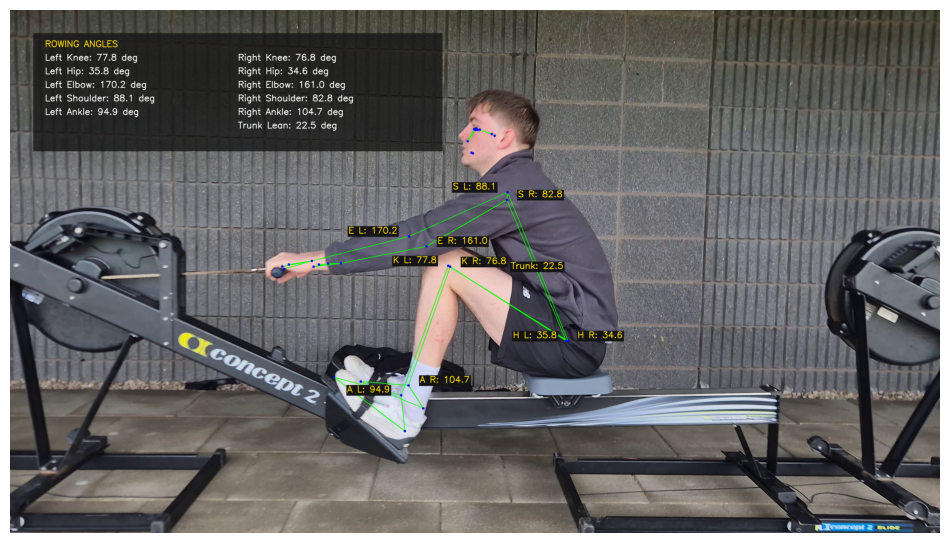

In [29]:
# draw each angle beside the joint it measures, as well as in an overview box
font_scale = max(0.55, width / 3200)
text_thickness = max(1, round(font_scale * 1.5))
joint_for_angle = {
    "knee": "knee",
    "hip": "hip",
    "elbow": "elbow",
    "shoulder": "shoulder",
    "ankle": "ankle",
}
short_name = {
    "knee": "K",
    "hip": "H",
    "elbow": "E",
    "shoulder": "S",
    "ankle": "A",
}

for side in ("left", "right"):
    for angle_name, joint_name in joint_for_angle.items():
        angle = rowing_angles[f"{side}_{angle_name}"]
        joint = get_point(landmarks[ROWING_LANDMARKS[f"{side}_{joint_name}"]], width, height)
        text = f"{short_name[angle_name]} {side[0].upper()}: {angle:.1f}"
        (text_width, text_height), baseline = cv2.getTextSize(
            text, cv2.FONT_HERSHEY_SIMPLEX, font_scale, text_thickness
        )
        side_offset = round(width * 0.012)
        if side == "left":
            text_x = round(joint[0]) - side_offset - text_width
        else:
            text_x = round(joint[0]) + side_offset
        text_y = round(joint[1]) - round(text_height / 2)
        text_x = min(max(text_x, 2), width - text_width - 4)
        text_y = min(max(text_y, text_height + baseline + 2), height - baseline - 2)
        cv2.rectangle(
            annotated,
            (text_x - 3, text_y - text_height - 3),
            (text_x + text_width + 3, text_y + baseline + 2),
            (20, 20, 20),
            cv2.FILLED,
        )
        cv2.putText(
            annotated,
            text,
            (text_x, text_y),
            cv2.FONT_HERSHEY_SIMPLEX,
            font_scale,
            (0, 220, 255),
            text_thickness,
            cv2.LINE_AA,
        )

shoulder_midpoint = (
    get_point(landmarks[ROWING_LANDMARKS["left_shoulder"]], width, height)
    + get_point(landmarks[ROWING_LANDMARKS["right_shoulder"]], width, height)
) / 2
hip_midpoint = (
    get_point(landmarks[ROWING_LANDMARKS["left_hip"]], width, height)
    + get_point(landmarks[ROWING_LANDMARKS["right_hip"]], width, height)
) / 2
trunk_midpoint = (shoulder_midpoint + hip_midpoint) / 2
trunk_text = f"Trunk: {rowing_angles['trunk_lean']:.1f}"
(trunk_width, trunk_height), trunk_baseline = cv2.getTextSize(
    trunk_text, cv2.FONT_HERSHEY_SIMPLEX, font_scale, text_thickness
)
trunk_x = min(max(round(trunk_midpoint[0] - trunk_width / 2), 2), width - trunk_width - 4)
trunk_y = min(max(round(trunk_midpoint[1]), trunk_height + trunk_baseline + 2), height - trunk_baseline - 2)
cv2.rectangle(
    annotated,
    (trunk_x - 3, trunk_y - trunk_height - 3),
    (trunk_x + trunk_width + 3, trunk_y + trunk_baseline + 2),
    (20, 20, 20),
    cv2.FILLED,
)
cv2.putText(
    annotated,
    trunk_text,
    (trunk_x, trunk_y),
    cv2.FONT_HERSHEY_SIMPLEX,
    font_scale,
    (0, 220, 255),
    text_thickness,
    cv2.LINE_AA,
)

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis("off");